## Predicting Diabetes with Machine Learning


In [41]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import warnings
warnings.filterwarnings("ignore")

In [42]:
df = pd.read_csv("diabetes.csv")

In [43]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [44]:
df.shape

(768, 9)

In [45]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [46]:
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

<Axes: >

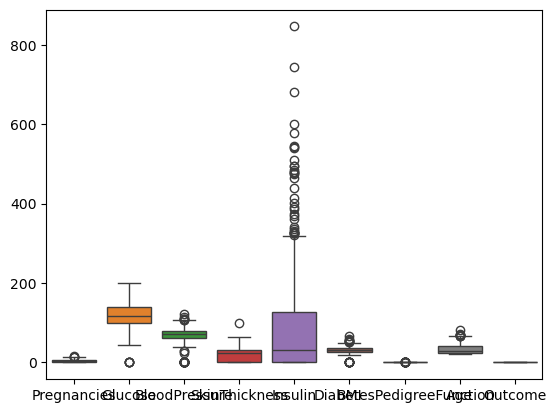

In [47]:
sns.boxplot(df)

In [48]:
df.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

In [49]:
def remove_outlier(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3-Q1 
    lower = Q1- 1.5*IQR
    upper = Q3+ 1.5*IQR
    return df[(df[column]>=lower) & (df[column]<=upper)]


<Axes: >

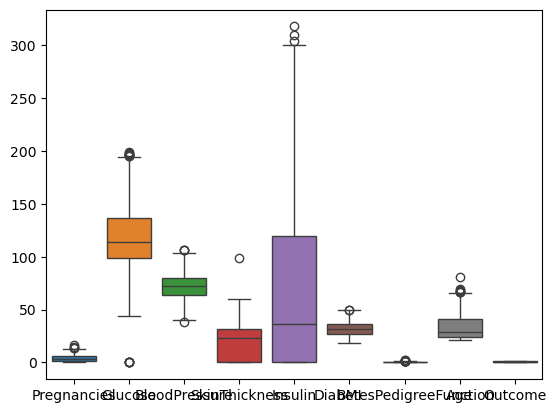

In [50]:
df = remove_outlier(df, "Insulin")
df = remove_outlier(df, "BloodPressure")
df = remove_outlier(df, "BMI")

sns.boxplot(df)

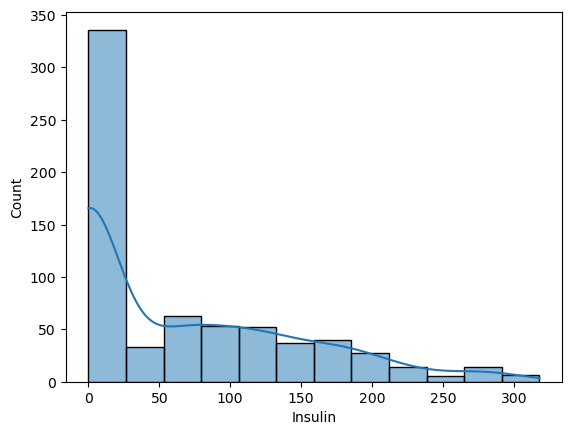

In [51]:
sns.histplot( data =df, x = "Insulin", kde = True)
plt.show()

array([[<Axes: title={'center': 'Pregnancies'}>,
        <Axes: title={'center': 'Glucose'}>,
        <Axes: title={'center': 'BloodPressure'}>],
       [<Axes: title={'center': 'SkinThickness'}>,
        <Axes: title={'center': 'Insulin'}>,
        <Axes: title={'center': 'BMI'}>],
       [<Axes: title={'center': 'DiabetesPedigreeFunction'}>,
        <Axes: title={'center': 'Age'}>,
        <Axes: title={'center': 'Outcome'}>]], dtype=object)

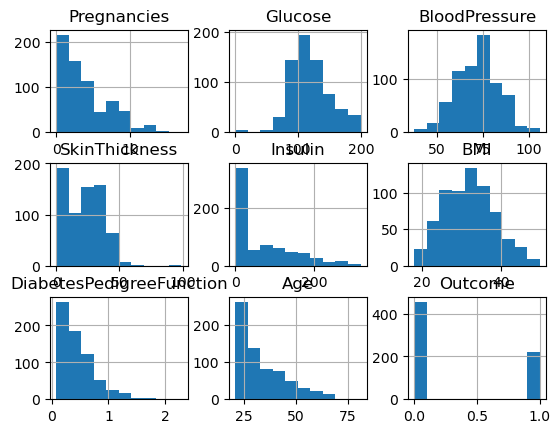

In [52]:
df.hist()

<Axes: >

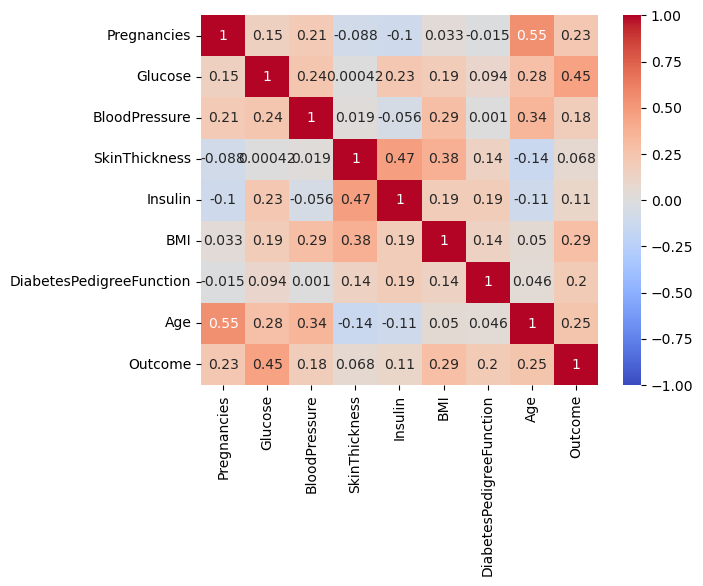

In [53]:
corrmatrix = df.corr()
sns.heatmap(corrmatrix, vmin = -1, vmax = 1, annot = True, cmap ="coolwarm")

In [54]:
x = df.drop("Outcome", axis = 1)
y =df['Outcome']

In [55]:
x.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,6,148,72,35,0,33.6,0.627,50
1,1,85,66,29,0,26.6,0.351,31
2,8,183,64,0,0,23.3,0.672,32
3,1,89,66,23,94,28.1,0.167,21
4,0,137,40,35,168,43.1,2.288,33


In [56]:
y

0      1
1      0
2      1
3      0
4      1
      ..
763    0
764    0
765    0
766    1
767    0
Name: Outcome, Length: 680, dtype: int64

In [57]:
from sklearn.preprocessing import StandardScaler

In [58]:
from sklearn import preprocessing
standadisation=StandardScaler()
x=standadisation.fit_transform(x)
#Coverting to Dataframe
x=pd.DataFrame(x)
x.describe()

,0,1,2,3,4,5,6,7
count,6.800000e+02,6.800000e+02,6.800000e+02,6.800000e+02,6.800000e+02,6.800000e+02,6.800000e+02,6.800000e+02
mean,1.567374e-17,1.227776e-16,3.186993e-16,1.018793e-16,-3.657205e-17,4.258032e-16,2.089832e-17,2.155139e-16
std,1.000736e+00,1.000736e+00,1.000736e+00,1.000736e+00,1.000736e+00,1.000736e+00,1.000736e+00,1.000736e+00
min,-1.148239e+00,-3.786165e+00,-3.002095e+00,-1.336410e+00,-8.241426e-01,-2.166861e+00,-1.235225e+00,-1.048244e+00
25%,-8.507905e-01,-6.348114e-01,-7.119224e-01,-1.336410e+00,-8.241426e-01,-7.423305e-01,-7.045928e-01,-7.915929e-01
50%,-2.558933e-01,-1.573336e-01,-7.253941e-03,1.422920e-01,-3.730927e-01,-6.583964e-03,-2.931142e-01,-3.638408e-01
75%,6.364526e-01,5.747990e-01,6.974146e-01,7.209147e-01,6.793571e-01,6.352374e-01,4.654997e-01,6.627640e-01
max,3.908387e+00,2.548374e+00,2.987587e+00,5.028439e+00,3.160132e+00,2.764206e+00,5.786918e+00,4.084780e+00


In [59]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, random_state = 42, test_size=0.33)

In [60]:
from sklearn.linear_model import LogisticRegression

In [61]:
log_model = LogisticRegression()

In [62]:
log_model.fit(x_train, y_train)

LogisticRegression()

In [63]:
y_pred = log_model.predict(x_test)

In [64]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [65]:
accuracy = accuracy_score(y_test, y_pred)
accuracy

0.7511111111111111

In [66]:
print("classification_report\n :", classification_report(y_test, y_pred))
classification_report

classification_report
 :               precision    recall  f1-score   support

           0       0.81      0.84      0.83       158
           1       0.59      0.54      0.56        67

    accuracy                           0.75       225
   macro avg       0.70      0.69      0.69       225
weighted avg       0.75      0.75      0.75       225



<function sklearn.metrics._classification.classification_report(y_true, y_pred, *, labels=None, target_names=None, sample_weight=None, digits=2, output_dict=False, zero_division='warn')>

Text(0.5, 1.0, 'Confusion Matrix')

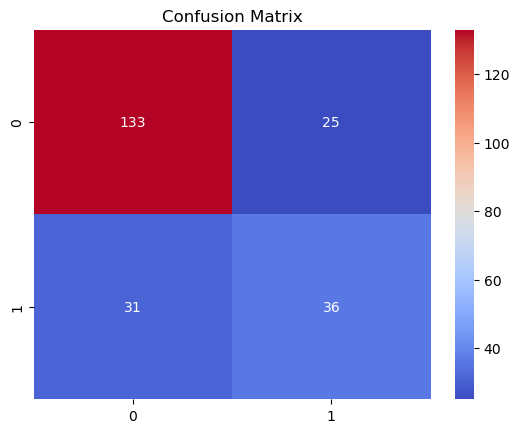

In [71]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap="coolwarm")
plt.title('Confusion Matrix')